In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Data Importing

In [24]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [28]:
data = df.copy()

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

missing_data = data[data['TotalCharges'].isna()]
print("Missing TotalCharges: ", missing_data.shape[0], "rows")

Missing TotalCharges:  11 rows


In [ ]:

data["TotalCharges"] = data["TotalCharges"].fillna(0)
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})


## Overview Data Exploratory

In [33]:
churn_rate = data['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 26.54%


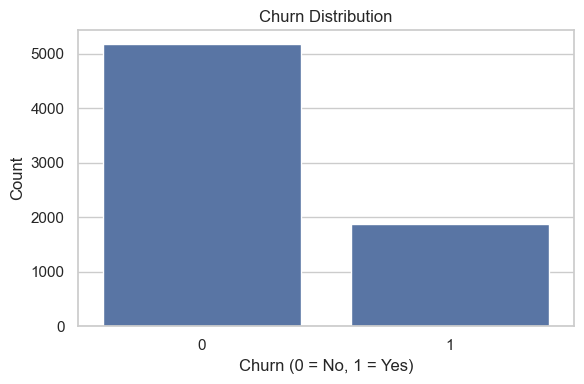

In [37]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [51]:
def churn_by(df, by_column, target='Churn'):
    dt = df.groupby(by_column)[target].mean().sort_values(ascending=True)
    print(dt)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=dt.index, y=dt.values)
    plt.title(f"{target} by {by_column}")
    plt.xlabel(f'{by_column}')
    plt.ylabel(f'{target}')
    plt.tight_layout()
    plt.show()


Contract
Two year          0.028319
One year          0.112695
Month-to-month    0.427097
Name: Churn, dtype: float64


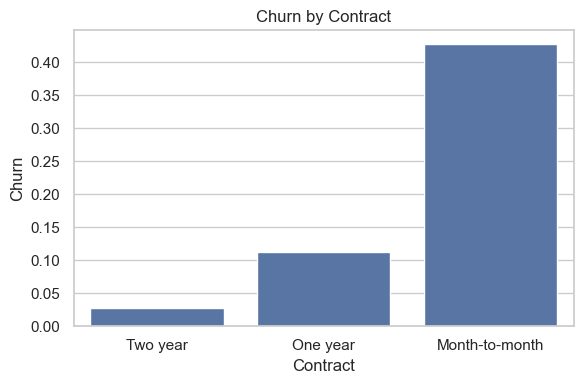

In [ ]:
#Churn Rate by Contract
churn_by(data, 'Contract')

TechSupport
No internet service    0.074050
Yes                    0.151663
No                     0.416355
Name: Churn, dtype: float64


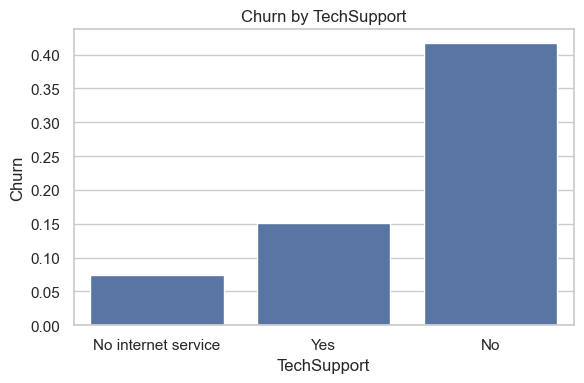

In [53]:
#Churn Rate by Tech Support
churn_by(data, 'TechSupport')

InternetService
No             0.074050
DSL            0.189591
Fiber optic    0.418928
Name: Churn, dtype: float64


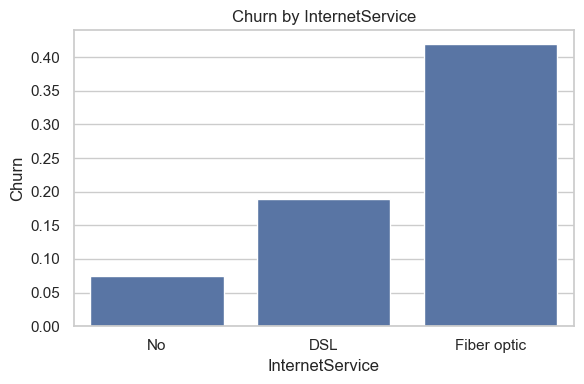

In [54]:
#Churn Rate by Internet Service
churn_by(data, 'InternetService')

PaymentMethod
Credit card (automatic)      0.152431
Bank transfer (automatic)    0.167098
Mailed check                 0.191067
Electronic check             0.452854
Name: Churn, dtype: float64


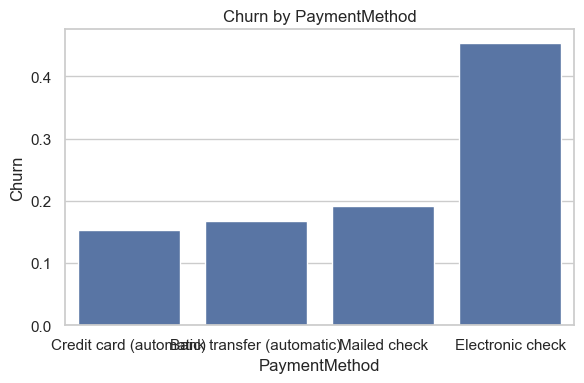

In [55]:
#Churn Rate by Payment Method
churn_by(data, "PaymentMethod")

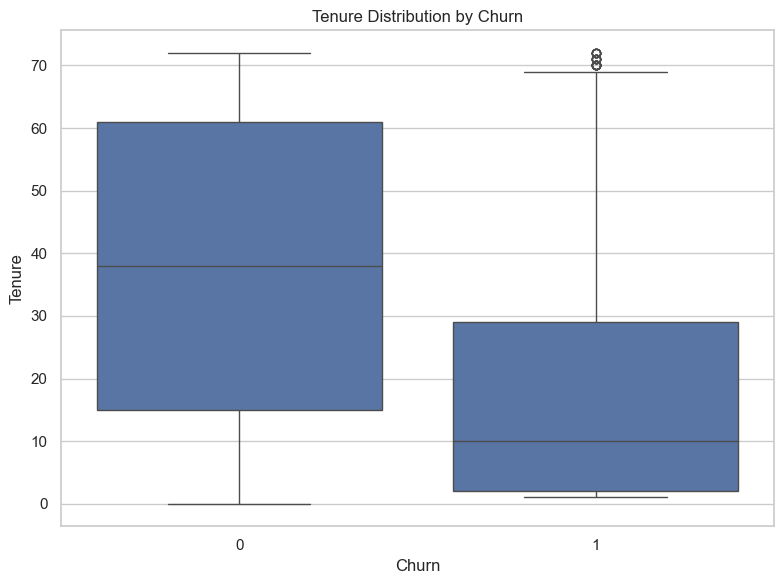

In [58]:
#Tenure distribution by churn
plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Churn', y='tenure')
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.tight_layout()
plt.show()

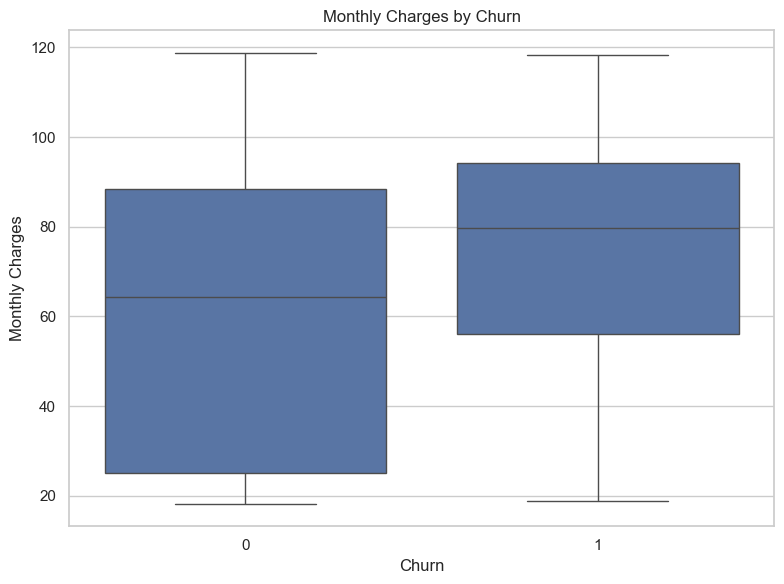

In [59]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

## Feature Engineering

In [61]:
feat = data.copy()

feat['avg_charge'] = feat["TotalCharges"] / (feat['tenure'] + 1)

feat['is_new_customer'] = (feat['tenure'] < 15).astype(int)

feat['has_family'] = ((feat['Partner'] == 'Yes') | (feat['Dependents'] == 'Yes')).astype(int)

addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
feat['addon_count'] = feat[addon_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

feat.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_charge,is_new_customer,has_family,addon_count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,1,1,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,0,0,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,1,0,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,0,0,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,1,0,0


In [64]:
baseline_data = data.copy()
improved_data = feat.copy()

baseline_data.shape, improved_data.shape

((7043, 21), (7043, 25))

## Preprocessing

In [74]:
#Helper functions

def split_xy(df, target_col="Churn"):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y
        )

def preprocessor(X):
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    num_cols = X.select_dtypes(exclude='object').columns.tolist()

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

    return preprocessor, num_cols, cat_cols

def evaluate(model, X_train, X_test, y_train, y_test, threshold=0.5, model_name="Model"):
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    auc = roc_auc_score(y_test, proba)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"=== {model_name} ===")
    print(f"AUC      : {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()
    print(classification_report(y_test, pred))

    return {
        "model": model_name,
        "proba": proba,
        "pred": pred,
        "auc": auc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def cross_validate_auc(model, X, y, model_name='Model'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring=["roc_auc", "precision", "recall", "f1"],
        n_jobs=-1
    )

    results = pd.DataFrame({
        "roc_auc": scores["test_roc_auc"],
        "precision": scores["test_precision"],
        "recall": scores["test_recall"],
        "f1": scores["test_f1"]
    })

    print(f"=== CV Results: {model_name} ===")
    print(results.mean().round(4))
    print()
    return results

In [72]:
X_train_base, X_test_base, y_train_base, y_test_base = split_xy(baseline_data)
X_train_imp, X_test_imp, y_train_imp, y_test_imp = split_xy(improved_data)

## Training

1. Baseline Logistic Regression

In [83]:
preprocessor_base, num_cols_base, cat_cols_base = preprocessor(X_train_base)

logreg_base = Pipeline([
    ("prep", preprocessor_base),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_result = evaluate(
    logreg_base,
    X_train_base, X_test_base,
    y_train_base, y_test_base,
    threshold=0.5,
    model_name="Baseline Logistic Regression"
)

=== Baseline Logistic Regression ===
AUC      : 0.8418
Precision: 0.6562
Recall   : 0.5615
F1-score : 0.6052

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [84]:
cv_X_base = baseline_data.drop(columns=["Churn"])
cv_y_base = baseline_data["Churn"]

baseline_cv = cross_validate_auc(
    logreg_base, cv_X_base, cv_y_base,
    model_name="Baseline Logistic Regression"
)

=== CV Results: Baseline Logistic Regression ===
roc_auc      0.8450
precision    0.6582
recall       0.5516
f1           0.6001
dtype: float64



2. Balanced Logistic Regression

In [90]:
logreg_balanced = Pipeline([
    ("prep", preprocessor_base),
    ('clf', LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'))
])

balanced_result = evaluate(
    logreg_balanced,
    X_train_base, X_test_base,
    y_train_base, y_test_base,
    threshold=0.5,
    model_name="Baseline Logistic Regression"
)

=== Baseline Logistic Regression ===
AUC      : 0.8410
Precision: 0.5251
Recall   : 0.7540
F1-score : 0.6191

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.77      1409



In [86]:
balanced_cv = cross_validate_auc(
    logreg_balanced, cv_X_base, cv_y_base,
    model_name="Balanced Logistic Regression"
)

=== CV Results: Balanced Logistic Regression ===
roc_auc      0.8448
precision    0.5376
recall       0.7635
f1           0.6308
dtype: float64



3. Improved Logistic Regression

In [ ]:
preprocessor_imp, num_cols_imp, cat_cols_imp = preprocessor(X_train_imp)

logreg_imp = Pipeline([
    ("prep", preprocessor_imp),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

imp_result = evaluate(
    logreg_imp,
    X_train_imp, X_test_imp,
    y_train_imp, y_test_imp,
    threshold=0.5,
    model_name="Improved Logistic Regression"
)

=== Improved Logistic Regression ===
AUC      : 0.8466
Precision: 0.6746
Recall   : 0.5321
F1-score : 0.5949

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [81]:
cv_X_imp = improved_data.drop(columns=["Churn"])
cv_y_imp = improved_data["Churn"]

improved_cv = cross_validate_auc(
    logreg_imp, cv_X_imp, cv_y_imp,
    model_name="Improved Logistic Regression"
)

=== CV Results: Improved Logistic Regression ===
roc_auc      0.8475
precision    0.6755
recall       0.5286
f1           0.5930
dtype: float64



4. Random Forest Classification

In [87]:
rf_base = Pipeline([
    ("prep", preprocessor_imp),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_result = evaluate(
    rf_base,
    X_train_imp, X_test_imp,
    y_train_imp, y_test_imp,
    threshold=0.5,
    model_name="Random Forest"
)

=== Random Forest ===
AUC      : 0.8284
Precision: 0.6608
Recall   : 0.5053
F1-score : 0.5727

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [88]:
rf_cv = cross_validate_auc(
    rf_base, cv_X_imp, cv_y_imp,
    model_name="Random Forest"
)

=== CV Results: Random Forest ===
roc_auc      0.8316
precision    0.6506
recall       0.4853
f1           0.5557
dtype: float64



## Summary

In [92]:
comparison = pd.DataFrame([
    {
        "Model": "Baseline Logistic",
        "AUC": baseline_result["auc"],
        "Precision": baseline_result["precision"],
        "Recall": baseline_result["recall"],
        "F1": baseline_result["f1"]
    },
    {
        "Model": "Balanced Logistic",
        "AUC": balanced_result["auc"],
        "Precision": balanced_result["precision"],
        "Recall": balanced_result["recall"],
        "F1": balanced_result["f1"]
    },
    {
        "Model": "Improved Logistic",
        "AUC": imp_result["auc"],
        "Precision": imp_result["precision"],
        "Recall": imp_result["recall"],
        "F1": imp_result["f1"]
    },
    {
        "Model": "Random Forest",
        "AUC": rf_result["auc"],
        "Precision": rf_result["precision"],
        "Recall": rf_result["recall"],
        "F1": rf_result["f1"]
    }
])

comparison.sort_values("AUC", ascending=False)

,Model,AUC,Precision,Recall,F1
2,Improved Logistic,0.846638,0.674576,0.532086,0.594918
0,Baseline Logistic,0.841032,0.525140,0.754011,0.619100
1,Balanced Logistic,0.841032,0.525140,0.754011,0.619100
3,Random Forest,0.828418,0.660839,0.505348,0.572727
